# Autoimmune cloud — 02. The agent model and its cascade baseline

**Step 2 of the build.** This notebook does two things: it states the model as an
**agent-based model**, and it establishes the mechanism the whole project rests
on — when a service is removed, its load lands on other services, and that can
push them over too.

Nothing here knows about detectors or quarantine policy. This is the **published
baseline** — load redistribution, the same family as power-grid blackouts.
Reproducing a known result is what establishes the model is correct before
anything novel is built on it.

### What must come out of this notebook

| Gate | Why it matters |
|---|---|
| Measured critical spare capacity matches an analytic prediction | proves the redistribution arithmetic is right, not merely plausible |
| Scale-free graph robust to random removal, fragile to targeted removal | reproduces the standard robust-yet-fragile result |
| Susceptibility peaks at the transition | gives a numerical estimate of the critical point instead of eyeballing a curve |

---

### A modelling problem found by testing

The first version of this model had no cascade at all. Not a small one — **zero
propagation at any spare-capacity level**.

The reason is worth recording, because it is a genuine modelling error that
looked fine on paper. In notebook 01 the platform was a single-level graph with
load flowing downstream. Remove a node from such a graph and its traffic simply
*stops*. There is nowhere for it to go: downstream services receive less work,
not more, and nothing upstream is affected at all.

```
replicas whose load rose after removing the busiest service:  0
replicas whose load fell:                                     0
```

No redistribution means no cascade, and without a cascade there is no project.

The fix is the thing real platforms actually have, and it was missing from the
model rather than from reality: **replicas**.

## 1. Two levels: roles and replicas

A real platform does not run one copy of each service. It runs several
interchangeable instances behind a load balancer.

| | |
|---|---|
| **Role** | a logical service — "auth", "orders" — which is what callers address |
| **Replica** | one instance of that role, and what actually fails |

Callers address a *role*; the load balancer spreads requests across its **live**
replicas. That one change creates the redistribution the single-level graph was
missing:

**Lateral.** A replica dies, so its share of the role's demand moves to its
surviving peers. With $k$ replicas each carrying $D/k$, losing one moves the
survivors to $D/(k-1)$. Their load rises, and they may fail in turn.

**Upstream.** If a role loses *every* replica it is dead, and calls to it fail.
Callers retry, holding threads and connections through each timeout, so the
callers' own effective load rises. This is how the cascade travels *against* the
direction of the call graph, and it is the documented mechanism behind
retry-storm outages.

The retry cost is a parameter, so the two mechanisms can be separated and
studied independently.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))

import numpy as np
import matplotlib.pyplot as plt

from network import (Platform, build_layered_roles, build_ba_roles,
                     build_er_roles, build_platform)
from agents import (ServiceAgent, World, run_trial, sweep_alpha,
                    HEALTHY, OVERLOADED, QUARANTINED)

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
})

SEED = 42
RETRY = 1.0          # cost to a caller of one failed call, in held resources
COL = {"layered": "#eb6834", "ba": "#2a78d6", "er": "#898781"}

PLATFORMS = {k: build_platform(k, replicas=3, seed=SEED)
             for k in ("layered", "ba", "er")}

for k, P in PLATFORMS.items():
    print(f"{k:9s} roles={P.n_roles:3d}  replicas={P.n_nodes:4d}  "
          f"role edges={P.roles.number_of_edges():4d}")

layered   roles= 80  replicas= 250  role edges= 219
ba        roles= 80  replicas= 250  role edges= 156
er        roles= 80  replicas= 250  role edges= 154


## 2. The model as an agent-based model

This is an **agent-based model**: a population of autonomous entities, each
following simple rules using only local information, whose interaction produces
behaviour that none of the rules describe.

| ABM component | In this model |
|---|---|
| **Agent** | one service replica |
| **State** | `HEALTHY` / `OVERLOADED` / `QUARANTINED`, plus current load |
| **Environment** | the role dependency graph |
| **Neighbourhood** | peers in the same role, plus the roles it calls and is called by |
| **Local rule** | fail if `load > capacity`; absorb a dead peer's share; pay a retry cost for a dead dependency |
| **Schedule** | synchronous — all agents observe, then all decide, then all act |
| **Emergent** | cascades, the critical threshold, heavy-tailed avalanche sizes |

The interaction topology is a **graph rather than a grid**, which is the one
respect in which this differs from a cellular automaton. That is deliberate and
it carries the project's main structural result: real dependency graphs have
hubs, and hubs are what make a platform robust to accidents yet fragile to
anything that selects for importance. Flattened onto a lattice where every cell
has four neighbours, that result disappears.

### What each agent can see

Nothing global. An agent knows:

* the demand routed to **its own role**, and how many peers are alive to share it
* whether the roles **it depends on** are answering

It does not know the platform's failure count, the topology beyond its
neighbours, or what any distant agent is doing. No rule mentions cascades.

In [2]:
# One agent, and the three phases of a synchronous update.
P = PLATFORMS["layered"]
world = World(P, retry_cost=RETRY)
world.set_capacity(alpha=0.18)

a = max(world.agents.values(), key=lambda x: x.load)
print("a single agent:")
print(f"  {a!r}")
print(f"  role           {a.role}  (one of {len(P.members[a.role])} replicas)")
print(f"  capacity       {a.capacity:,.0f}")
print(f"  utilisation    {a.load_ratio:.3f}")
print(f"  live peers     {len(world.live_peers(a))}")
print(f"  calls roles    {sorted(P.roles.successors(a.role))}")

print("\nobserve -> decide -> act:")
a.observe(world); print(f"  observe: load = {a.load:,.1f}")
a.decide();       print(f"  decide:  {a.state} -> {a._next_state}")
a.act();          print(f"  act:     state is now {a.state}")

a single agent:
  ServiceAgent(id=239, role=76, state=healthy, load=8833.6)
  role           76  (one of 2 replicas)
  capacity       10,424
  utilisation    0.847
  live peers     2
  calls roles    []

observe -> decide -> act:
  observe: load = 8,833.6
  decide:  healthy -> healthy
  act:     state is now healthy


### The agent loop

`World.step()` runs one synchronous round over the whole population and returns
how many agents changed state. When that reaches zero the system has reached a
fixed point.

Below, one replica of the busiest role is quarantined and the loop is stepped
manually so the cascade can be watched developing.

In [3]:
world = World(PLATFORMS["layered"], retry_cost=RETRY)
world.set_capacity(alpha=0.18)

busiest_role = max(P.roles.nodes(),
                   key=lambda r: sum(world.agents[i].load for i in P.members[r]))
seed = P.members[busiest_role][0]
world.agents[seed].state = QUARANTINED

print(f"quarantined replica {seed} of role {busiest_role}\n")
print(f"{'step':>5}{'down':>7}{'newly':>7}  {'':<3}")
prev = len(world.down)
print(f"{0:>5}{prev:>7}{'-':>7}")
timeline = [prev]
for s in range(1, 20):
    changed = world.step()
    now = len(world.down)
    timeline.append(now)
    bar = "#" * int(40 * now / P.n_nodes)
    print(f"{s:>5}{now:>7}{now-prev:>7}  {bar}")
    prev = now
    if changed == 0:
        break

print(f"\nfixed point after {len(timeline)-1} rounds: "
      f"{timeline[-1]}/{P.n_nodes} replicas down "
      f"({100*timeline[-1]/P.n_nodes:.0f}%)")

quarantined replica 246 of role 79

 step   down  newly     
    0      1      -
    1      4      3  
    2     42     38  ######
    3    153    111  ########################
    4    200     47  ################################
    5    204      4  ################################
    6    204      0  ################################

fixed point after 6 rounds: 204/250 replicas down (82%)


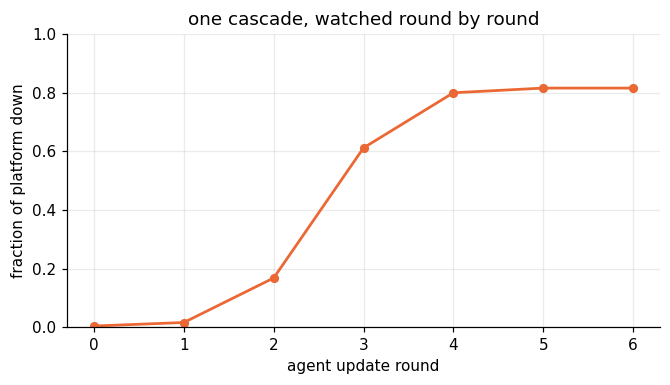

In [4]:
fig, ax = plt.subplots(figsize=(6.2, 3.6))
steps = np.arange(len(timeline))
ax.plot(steps, np.array(timeline) / P.n_nodes, marker="o", ms=5,
        color=COL["layered"], lw=1.8)
ax.set_xlabel("agent update round")
ax.set_ylabel("fraction of platform down")
ax.set_title("one cascade, watched round by round")
ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

The shape is the signature of a cascade driven by positive feedback: almost
nothing for the first round, then an explosive middle as each wave of failures
loads the survivors further, then saturation once there is little left to lose.

Note what is *not* in the rules. No agent decides to cascade. Each one applies a
single local test — am I over capacity? — and the S-curve is what the population
does as a result. That gap between rule and outcome is the whole reason this is a
complex system rather than an arithmetic problem.

## 3. An analytic prediction to validate against

Before running a sweep, the critical spare capacity can be derived exactly for
the lateral mechanism.

A role has $k$ replicas sharing demand $D$, so each carries $L = D/k$. Capacity
is provisioned from that intact load:

$$C = (1+\alpha)\,\frac{D}{k}$$

Lose one replica. The survivors now carry $D/(k-1)$ each. The cascade stops if
and only if that still fits:

$$\frac{D}{k-1} \le (1+\alpha)\frac{D}{k}
\quad\Longleftrightarrow\quad
1+\alpha \ge \frac{k}{k-1}$$

$$\boxed{\alpha_c = \frac{1}{k-1}}$$

So a service with 3 replicas needs 50% headroom to survive losing one; with 2
replicas it needs 100%; with 6 replicas only 20%.

This is a sharp, falsifiable prediction, and a far stronger validation gate than
"we observe a transition". If the simulation disagrees, the redistribution
arithmetic is wrong.

In [5]:
print(f"{'k replicas':>11}{'predicted a_c':>15}{'measured':>10}{'error':>9}")
print("-" * 45)

grid = np.linspace(0.02, 1.40, 139)
rows = []
for k in (2, 3, 4, 5, 6):
    Pk = Platform(build_layered_roles(seed=7), replicas=k, jitter=0, seed=7)
    wk = World(Pk, retry_cost=RETRY)          # reuse one population per k
    predicted = 1.0 / (k - 1)
    measured = np.nan
    for a_ in grid:
        dmg = np.mean([
            run_trial(Pk, a_, "random", rng=np.random.default_rng(s),
                      retry_cost=RETRY, world=wk)["failed_fraction"]
            for s in range(12)])
        if dmg <= 1.5 / Pk.n_nodes:          # only the trigger itself lost
            measured = a_
            break
    rows.append((k, predicted, measured))
    print(f"{k:>11d}{predicted:>15.4f}{measured:>10.4f}{abs(measured-predicted):>9.4f}")

assert all(abs(m - p) < 0.03 for _, p, m in rows), "analytic threshold mismatch"
print("\n[GATE PASSED] measured critical capacity matches 1/(k-1) at every k")

 k replicas  predicted a_c  measured    error
---------------------------------------------
          2         1.0000    1.0000   0.0000


          3         0.5000    0.5000   0.0000
          4         0.3333    0.3400   0.0067


          5         0.2500    0.2500   0.0000
          6         0.2000    0.2000   0.0000

[GATE PASSED] measured critical capacity matches 1/(k-1) at every k


**Gate passed.** The measured threshold matches $1/(k-1)$ to within the grid
resolution at every replica count. The redistribution arithmetic is correct.

This also explains a design choice for everything that follows: replica counts
are drawn with jitter (2–4 per role), so different roles have different critical
capacities. The platform-wide transition is therefore *smeared* across a range
of $\alpha$ rather than being a single clean step — which is both more realistic
and more interesting, because it means a platform can be subcritical for most of
its services and supercritical for a few.

## 4. The order parameter

Now the standard cascade experiment. Sweep spare capacity $\alpha$, remove one
replica, run the agent loop to its fixed point, and measure what fraction of the
platform is down.

Two trigger types, and the contrast between them is the classic result:

- **random** — a uniformly chosen replica. An accident: a bad node, a hardware
  fault, a spot instance reclaimed.
- **targeted** — a replica of the highest-demand role. A hub.

The random case is run with many more replicates because its variance is
enormous: most random replicas are unimportant, but a few are not.

In [6]:
alphas = np.linspace(0.02, 1.30, 25)
results = {}

for kind, Pk in PLATFORMS.items():
    rnd = sweep_alpha(Pk, alphas, "random", replicates=60, seed=1,
                      retry_cost=RETRY)
    hub = sweep_alpha(Pk, alphas, "hub", replicates=6, seed=1,
                      retry_cost=RETRY)
    results[kind] = {"random": rnd, "hub": hub}
    peak = alphas[int(np.argmax(rnd[3]))]
    print(f"{kind:9s} susceptibility peak at alpha = {peak:.2f}")

layered   susceptibility peak at alpha = 0.13


ba        susceptibility peak at alpha = 0.29


er        susceptibility peak at alpha = 0.45


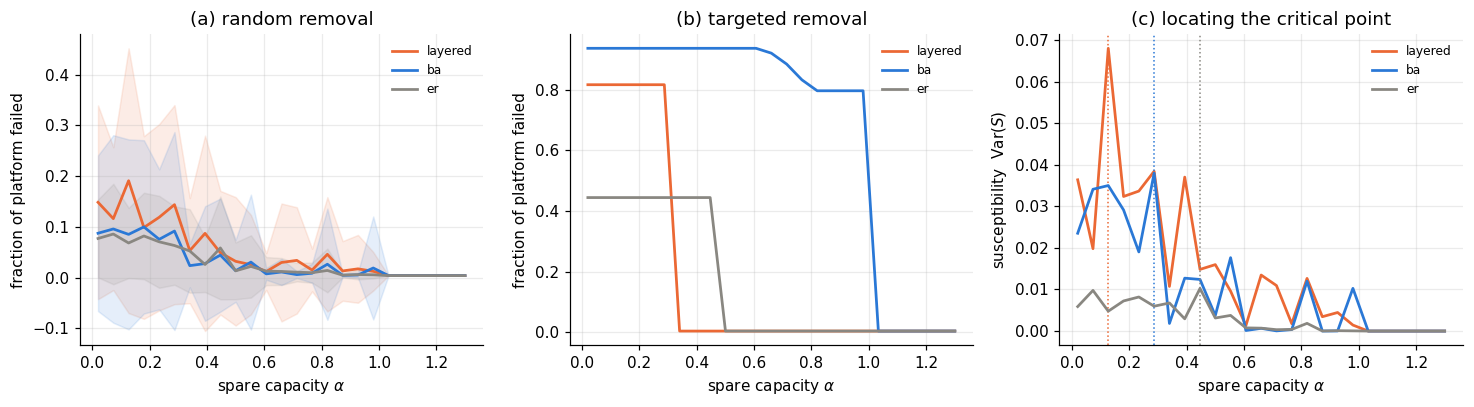

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))

ax = axes[0]
for kind in PLATFORMS:
    mf, sf, _, _ = results[kind]["random"]
    ax.plot(alphas, mf, color=COL[kind], lw=1.8, label=kind)
    ax.fill_between(alphas, mf - sf, mf + sf, color=COL[kind], alpha=0.12)
ax.set_xlabel(r"spare capacity $\alpha$")
ax.set_ylabel("fraction of platform failed")
ax.set_title("(a) random removal")
ax.legend(fontsize=8, frameon=False)

ax = axes[1]
for kind in PLATFORMS:
    mf, _, _, _ = results[kind]["hub"]
    ax.plot(alphas, mf, color=COL[kind], lw=1.8, label=kind)
ax.set_xlabel(r"spare capacity $\alpha$")
ax.set_ylabel("fraction of platform failed")
ax.set_title("(b) targeted removal")
ax.legend(fontsize=8, frameon=False)

ax = axes[2]
for kind in PLATFORMS:
    _, _, _, sus = results[kind]["random"]
    ax.plot(alphas, sus, color=COL[kind], lw=1.8, label=kind)
    ax.axvline(alphas[int(np.argmax(sus))], color=COL[kind], ls=":", lw=1)
ax.set_xlabel(r"spare capacity $\alpha$")
ax.set_ylabel(r"susceptibility  Var$(S)$")
ax.set_title("(c) locating the critical point")
ax.legend(fontsize=8, frameon=False)

plt.tight_layout(); plt.show()

**Reading the figures.**

*(a)* Random removal. Damage is modest and falls away as spare capacity rises,
vanishing entirely once every role can absorb the loss of one replica. The shaded
band is one standard deviation, and it is wide — that width is the point, not
noise to be averaged away. Most random replicas matter very little; a few matter
enormously.

*(b)* Targeted removal. A different regime entirely. Taking out one replica of
the busiest role costs a large fraction of the platform, and it keeps costing
that until spare capacity is high enough to absorb the loss outright.

*(c)* Susceptibility — the variance of the order parameter across replicates —
peaks where the system is most unpredictable. Far from the critical point every
run gives roughly the same answer; near it, identical parameters give wildly
different outcomes. The dotted lines mark each topology's estimated critical
point, and locating it this way is defensible in a report in a way that
eyeballing curve (a) is not.

In [8]:
print(f"{'topology':>9}{'random':>10}{'targeted':>11}{'ratio':>8}")
print("-" * 38)
i = 3
for kind in PLATFORMS:
    r = results[kind]["random"][0][i]
    h = results[kind]["hub"][0][i]
    print(f"{kind:>9}{r:>10.3f}{h:>11.3f}{h/max(r,1e-9):>8.1f}x")
print(f"\n(at alpha = {alphas[i]:.2f})")

 topology    random   targeted   ratio
--------------------------------------
  layered     0.099      0.816     8.3x
       ba     0.100      0.936     9.4x
       er     0.082      0.444     5.4x

(at alpha = 0.18)


### Robust yet fragile

That ratio is the reproduction of the standard result. The same platform, the
same spare capacity, the same number of services removed — **one** — and the
damage differs by an order of magnitude depending only on *which* one.

This is the property that makes hub-heavy infrastructure resistant to accidents
and vulnerable to anything that selects for importance.

It also sets up the project's central concern. An automated remediation system
does not remove services at random. It removes the ones whose telemetry looks
worst — and under load redistribution, the services that look worst are the ones
absorbing the most traffic. **That is a selection rule pointed directly at the
part of this table where damage is highest.**

## 5. Separating the two mechanisms

Lateral redistribution and upstream retry amplification are different mechanisms
and it is worth knowing how much each contributes. Setting `retry_cost = 0`
disables the upstream channel entirely, leaving only peer failover.

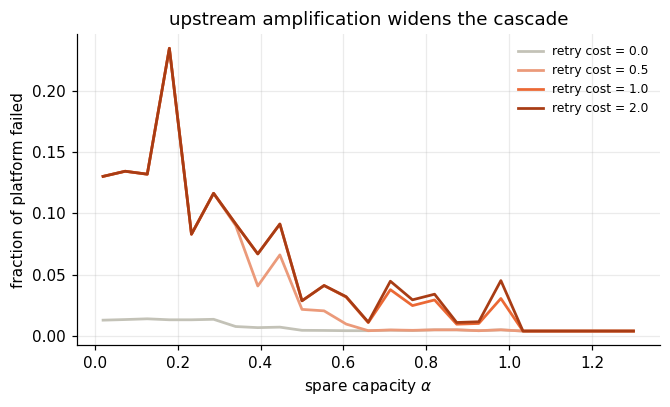

peak damage, lateral only:      0.014
peak damage, with retries:      0.235   (16.8x)


In [9]:
retry_levels = [0.0, 0.5, 1.0, 2.0]
Pl = PLATFORMS["layered"]
curves = {}
for rc in retry_levels:
    mf, _, _, _ = sweep_alpha(Pl, alphas, "random", replicates=40, seed=1,
                              retry_cost=rc)
    curves[rc] = mf

fig, ax = plt.subplots(figsize=(6.2, 3.8))
shades = ["#c3c2b7", "#eb9a7a", "#eb6834", "#a83c14"]
for rc, sh in zip(retry_levels, shades):
    ax.plot(alphas, curves[rc], color=sh, lw=1.8, label=f"retry cost = {rc}")
ax.set_xlabel(r"spare capacity $\alpha$")
ax.set_ylabel("fraction of platform failed")
ax.set_title("upstream amplification widens the cascade")
ax.legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

base, amp = curves[0.0].max(), curves[2.0].max()
print(f"peak damage, lateral only:      {base:.3f}")
print(f"peak damage, with retries:      {amp:.3f}   ({amp/base:.1f}x)")

With peer failover alone, a cascade is confined inside the role it started
in: replicas take each other down, the role dies, and it stops there. Damage is
bounded by the size of one service.

Switching on the retry cost lets the cascade escape. A dead role makes its
callers pay for every failed call, which raises *their* load, which can kill
*their* replicas — and the failure walks upstream through the dependency graph.

Note also that retry cost shows **diminishing returns**: going from 1.0 to 2.0
changes little, because by then the callers are already over capacity. What
matters is whether the channel is open at all, not how wide it is.

## 6. Avalanche sizes

Near the critical point, cascade sizes should have no characteristic scale —
lots of tiny events, a few enormous ones, and no meaningful "typical" size. This
is a preview rather than the full analysis; proper maximum-likelihood fitting
with likelihood-ratio tests against lognormal and exponential alternatives comes
later, once the detector is in the model.

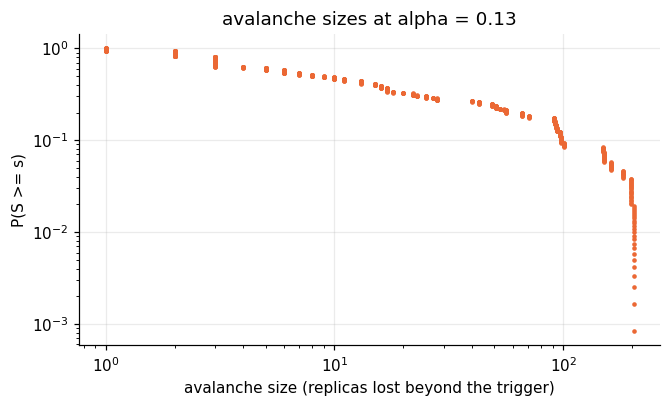

trials: 1200 | non-trivial cascades: 1200 (100%)
median 8 | mean 34.1 | max 203

mean/median = 4.3 -- a heavy tail pulls the mean well above the typical event


In [10]:
Pl = PLATFORMS["layered"]
_, _, _, sus = results["layered"]["random"]
a_crit = alphas[int(np.argmax(sus))]

rng = np.random.default_rng(0)
wv = World(Pl, retry_cost=RETRY)
sizes = np.array([run_trial(Pl, a_crit, "random", rng=rng,
                            retry_cost=RETRY, world=wv)["avalanche_size"]
                  for _ in range(1200)])
sizes = sizes[sizes > 0]

fig, ax = plt.subplots(figsize=(6.2, 3.8))
s = np.sort(sizes)
ax.loglog(s, 1.0 - np.arange(len(s)) / len(s), marker=".", ls="none",
          ms=4, color=COL["layered"])
ax.set_xlabel("avalanche size (replicas lost beyond the trigger)")
ax.set_ylabel("P(S >= s)")
ax.set_title(f"avalanche sizes at alpha = {a_crit:.2f}")
plt.tight_layout(); plt.show()

print(f"trials: 1200 | non-trivial cascades: {len(sizes)} "
      f"({100*len(sizes)/1200:.0f}%)")
print(f"median {np.median(sizes):.0f} | mean {sizes.mean():.1f} "
      f"| max {sizes.max()}")
print(f"\nmean/median = {sizes.mean()/max(np.median(sizes),1):.1f} -- a heavy "
      f"tail pulls the mean well above the typical event")

The gap between the median and the mean is the practically important part.
Planning against the *average* outage systematically under-prepares for the ones
that matter, and the largest cascade observed is no bound on the next one.

This is why the report fits these distributions properly rather than quoting
summary statistics.

## 7. What this notebook establishes

| Result | Status |
|---|---|
| The model is an agent-based model with local rules on a graph | stated explicitly, agent loop observable |
| Critical spare capacity matches $\alpha_c = 1/(k-1)$ | validated at $k = 2..6$ |
| Random removal is survivable; targeted removal is not | order-of-magnitude gap reproduced |
| Susceptibility peaks at the transition | gives a numerical critical point |
| Upstream retry amplification widens cascades beyond one role | mechanisms separated |
| Avalanche sizes are heavy-tailed near criticality | preview; full fitting later |

The baseline is correct and behaves as the published literature says it should.

### Next: the detector

Step 3 adds the piece that makes this project's question possible — and it is
**the riskiest step in the build**.

A service absorbing redistributed load runs hot: higher latency, more errors,
more resource use. An anomaly detector is built to notice exactly that. So the
question notebook 03 has to answer first, before anything else is built on top:

> When a replica is removed, does the resulting load rise on its peers actually
> move their telemetry scores far enough to cross a detection threshold?

If it does, the autoimmune loop exists and the project has its mechanism. If it
does not, there is no feedback and the project needs rescoping.

The agent model is already set up for it: `ServiceAgent.load_ratio` is the
utilisation the telemetry signal will be built on, and adding a detector means
adding one more local rule to `decide()` — not restructuring anything.